In [3]:
import json
from pathlib import Path

p = Path(r"./graphs/dallas-austin.json")
with p.open("r", encoding="utf-8") as f:
    base_graph = json.load(f)

print(type(base_graph))
base_nodes = {}
for node in base_graph['nodes']:
    base_nodes[node['feature']] = 0
    


<class 'dict'>


In [4]:
import re
import json
from pathlib import Path
from typing import Iterator, Tuple, Any

STEP_RE = re.compile(r"step[_\s]?0*(\d+)", flags=re.I)

# What 
def extract_step(name: str) -> int | None:
    m = STEP_RE.search(name)
    return int(m.group(1)) if m else None

# index every file in a folder by step and path
def iter_step_files(folder: str | Path, pattern: str = "step_*.json"
                   ) -> Iterator[Tuple[int, Path]]:
    folder = Path(folder)
    files = list(folder.glob(pattern))
    files.sort(key=lambda p: extract_step(p.name) or float("inf"))
    for fp in files:
        step = extract_step(fp.name)
        if step is None:
            continue
        yield step, fp

def load_steps(folder: str | Path, pattern: str = "step_*.json",
               value_key: str | None = None) -> dict[int, Any]:
    results: dict[int, Any] = {}
    for step, fp in iter_step_files(folder, pattern):
        try:
            with fp.open("r", encoding="utf-8") as f:
                data = json.load(f)
            results[step] = data.get(value_key, data) if (value_key and isinstance(data, dict)) else data
        except Exception as e:
            print(f"skipping {fp.name}: {e}")
    return results

# Example usage (adjust path if this notebook lives in notebooks/ -> ../graph_files_iterative)
folder = Path(r"c:\Users\Dell7420\Desktop\attribution-graph-for-cot\graph_files_iterative")
steps = load_steps(folder, pattern="step_*.json", value_key=None)  # set value_key="value" if JSON has a 'value' field

for step in sorted(steps):
    
    print(step, type(steps[step]), getattr(steps[step], '__len__', lambda: '')(), str(steps[step])[:200])

0 <class 'dict'> 4 {'metadata': {'slug': 'step_00_', 'scan': 'mntss/gemma-scope-transcoders', 'transcoder_list': [], 'prompt_tokens': ['<bos>', 'We', ' are', ' going', ' to', ' answer', ' things', ' step', ' by', ' step
1 <class 'dict'> 4 {'metadata': {'slug': 'step_01_The', 'scan': 'mntss/gemma-scope-transcoders', 'transcoder_list': [], 'prompt_tokens': ['<bos>', 'We', ' are', ' going', ' to', ' answer', ' things', ' step', ' by', ' s
2 <class 'dict'> 4 {'metadata': {'slug': 'step_02_capital', 'scan': 'mntss/gemma-scope-transcoders', 'transcoder_list': [], 'prompt_tokens': ['<bos>', 'We', ' are', ' going', ' to', ' answer', ' things', ' step', ' by',
3 <class 'dict'> 4 {'metadata': {'slug': 'step_03_of', 'scan': 'mntss/gemma-scope-transcoders', 'transcoder_list': [], 'prompt_tokens': ['<bos>', 'We', ' are', ' going', ' to', ' answer', ' things', ' step', ' by', ' st
4 <class 'dict'> 4 {'metadata': {'slug': 'step_04_the', 'scan': 'mntss/gemma-scope-transcoders', 'transcoder_list': [], 

In [5]:
def track_feature_persistence_v3(step_graphs_dict, min_layer=5):
    """
    Tracks persistence but filters out early layers (Input processing)
    and specific non-reasoning node types.
    """
    persistence_tracker = {}

    for step_num, graph_data in step_graphs_dict.items():
        if 'nodes' not in graph_data:
            continue
            
        for node in graph_data['nodes']:
            layer = node.get('layer', -1)
            feature = node.get('feature', -1)
            feature_type = node.get('feature_type', 'unknown') # check if this field exists
            
            # FILTER 1: Ignore Noise
            if feature == -1: continue
                
            # FILTER 2: Ignore Early Layers (Input Processing)
            # Adjust 'min_layer' based on model depth (Gemma-2b has ~26 layers)
            # Layers 0-5 are often just "syntax/input"
            try:
                if int(layer) < min_layer: continue
            except:
                continue # Skip if layer is not a number (e.g. 'E' for embedding)

            # FILTER 3: Ignore Embeddings explicitly (if labeled)
            if 'embedding' in str(feature_type).lower(): continue

            unique_id = f"{layer}.{feature}"
            
            if unique_id not in persistence_tracker:
                persistence_tracker[unique_id] = set()
            
            persistence_tracker[unique_id].add(step_num)

    return persistence_tracker

In [6]:

# --- Revised Analysis Block ---

tracker = track_feature_persistence_v3(steps)
total_steps = len(steps)

# Convert to list for sorting: (feature_id, count, percentage)
results = []
for fid, step_set in tracker.items():
    count = len(step_set)
    # Filter: Must be in at least 50% of steps to matter
    if count >= (total_steps * 0.5): 
        results.append((fid, count, count/total_steps))

# Sort by count (descending)
results.sort(key=lambda x: x[1], reverse=True)

print(f"Found {len(results)} persistent features out of {len(tracker)} total seen features.")
print("\nTop 10 Persistent Reasoning Features:")
for fid, count, pct in results[:10]:
    print(f"Feature {fid} active in {count}/{total_steps} steps ({pct:.1%})")

Found 84 persistent features out of 7150 total seen features.

Top 10 Persistent Reasoning Features:
Feature 6.2586668 active in 50/50 steps (100.0%)
Feature 8.1908072 active in 50/50 steps (100.0%)
Feature 5.7993995 active in 49/50 steps (98.0%)
Feature 6.8078183 active in 48/50 steps (96.0%)
Feature 7.110677 active in 48/50 steps (96.0%)
Feature 7.23595007 active in 48/50 steps (96.0%)
Feature 18.44514311 active in 47/50 steps (94.0%)
Feature 24.18147275 active in 47/50 steps (94.0%)
Feature 7.16528367 active in 46/50 steps (92.0%)
Feature 7.4828270 active in 46/50 steps (92.0%)


In [7]:
# --- Layer-wise Analysis ---
from collections import defaultdict

tracker = track_feature_persistence_v3(steps, min_layer=0) # Get everything first
layer_counts = defaultdict(list)

# Group by layer
for unique_id, step_set in tracker.items():
    layer = int(unique_id.split('.')[0])
    count = len(step_set)
    # Only keep fairly persistent ones (>50%)
    if count > (len(steps) * 0.5):
        layer_counts[layer].append(count)

print("Persistence Heatmap by Layer:")
for layer in sorted(layer_counts.keys()):
    num_persistent = len(layer_counts[layer])
    avg_persistence = sum(layer_counts[layer]) / num_persistent
    print(f"Layer {layer:02d}: {num_persistent} persistent features (Avg duration: {avg_persistence:.1f} steps)")

Persistence Heatmap by Layer:
Layer 00: 376 persistent features (Avg duration: 40.0 steps)
Layer 01: 55 persistent features (Avg duration: 35.0 steps)
Layer 02: 51 persistent features (Avg duration: 34.9 steps)
Layer 03: 31 persistent features (Avg duration: 34.8 steps)
Layer 04: 25 persistent features (Avg duration: 35.2 steps)
Layer 05: 9 persistent features (Avg duration: 33.0 steps)
Layer 06: 17 persistent features (Avg duration: 35.0 steps)
Layer 07: 11 persistent features (Avg duration: 38.0 steps)
Layer 08: 7 persistent features (Avg duration: 37.6 steps)
Layer 09: 8 persistent features (Avg duration: 34.5 steps)
Layer 10: 4 persistent features (Avg duration: 29.2 steps)
Layer 11: 1 persistent features (Avg duration: 32.0 steps)
Layer 13: 1 persistent features (Avg duration: 30.0 steps)
Layer 14: 2 persistent features (Avg duration: 34.5 steps)
Layer 15: 2 persistent features (Avg duration: 36.0 steps)
Layer 16: 1 persistent features (Avg duration: 32.0 steps)
Layer 17: 1 persis

In [5]:
node_labels = []
node_counts = []
for step in sorted(steps):
    matches = 0
    value = steps[step]['metadata']['slug']
    for node in steps[step]['nodes']:
        if node['feature'] in base_nodes:
            matches += 1
            base_nodes[node['feature']] += 1
    node_labels.append(value)
    node_counts.append(matches)

In [6]:
! pip install matplotlib

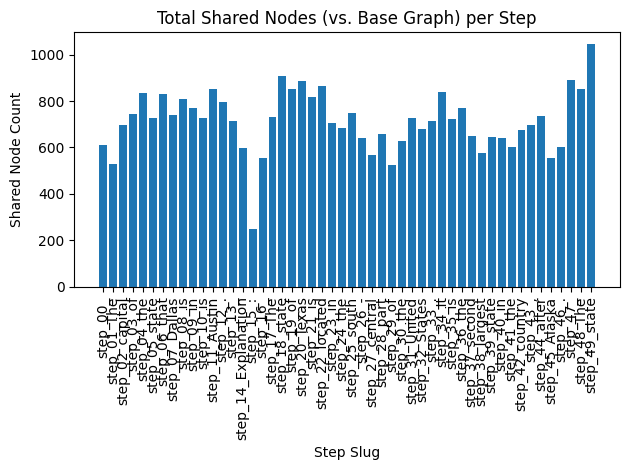

In [7]:
import matplotlib.pyplot as plt

plt.bar(node_labels, node_counts)

plt.xlabel("Step Slug")
plt.ylabel("Shared Node Count")
plt.title("Total Shared Nodes (vs. Base Graph) per Step")

plt.xticks(rotation=90)

# 4. Cleans up padding so labels don't get cut off
plt.tight_layout()

# 5. Display the final plot
plt.show()
